In [1]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [3]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [4]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

--2026-04-25 11:04:59--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz.1’

mito.npz.1          100%[===================>]  35.87M  88.5MB/s    in 0.4s    

2026-04-25 11:05:01 (88.5 MB/s) - ‘mito.npz.1’ saved [37610178/37610178]



In [5]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [6]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [7]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER
# It normalizes the data using min-max normalization

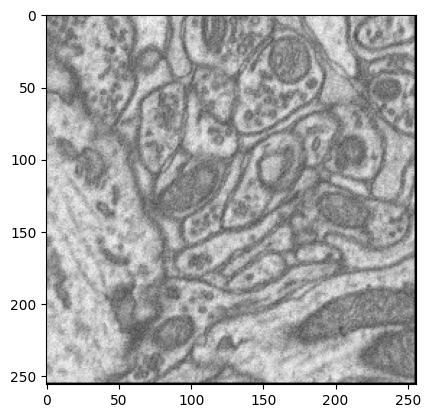

In [8]:
imshow(images[0], cmap='gray')

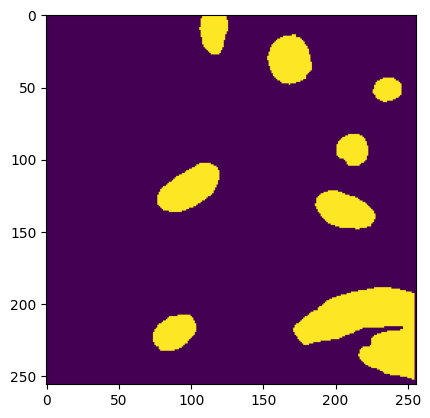

In [9]:
imshow(masks[0])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [11]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER
# We are splitting the data into train and test datasets for training and testing the neural network.

## 2. Make the Data Pytorch-ready! (10 points)

In [12]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [13]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [14]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER
# We are performing data augmentation to increase variety in the dataset and also increase the number of images in the dataset.

In [15]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [16]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [17]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER
# We are creating batches of data to feed to the neural network. First we created a custom Dataset class which is required to process
# our custom dataset and convert the images to tensor data. Then we pass those tensors to a DataLoader function which creates batches
# of those tensor data. Shuffling is also enabled for train data which does not allow the model to get used to a certain distribution of data
# and improves generalization and accuracy.

## 3. Configure the Classifier! (30 points)

In [18]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [19]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [20]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [21]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [22]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.5646, train_dice=0.5795 | val_loss=0.5133, val_dice=0.4570
Epoch 2/10 | train_loss=0.2863, train_dice=0.7939 | val_loss=0.2131, val_dice=0.8313
Epoch 3/10 | train_loss=0.1505, train_dice=0.8529 | val_loss=0.1232, val_dice=0.8589
Epoch 4/10 | train_loss=0.0996, train_dice=0.8878 | val_loss=0.1276, val_dice=0.8364
Epoch 5/10 | train_loss=0.0769, train_dice=0.9078 | val_loss=0.1038, val_dice=0.8571
Epoch 6/10 | train_loss=0.0692, train_dice=0.9128 | val_loss=0.0987, val_dice=0.8539
Epoch 7/10 | train_loss=0.0598, train_dice=0.9220 | val_loss=0.0550, val_dice=0.9276
Epoch 8/10 | train_loss=0.0571, train_dice=0.9270 | val_loss=0.2429, val_dice=0.6994
Epoch 9/10 | train_loss=0.0617, train_dice=0.9186 | val_loss=0.0650, val_dice=0.9107
Epoch 10/10 | train_loss=0.0575, train_dice=0.9229 | val_loss=0.0928, val_dice=0.8582
Best val dice: 0.9275734083993095


In [23]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE

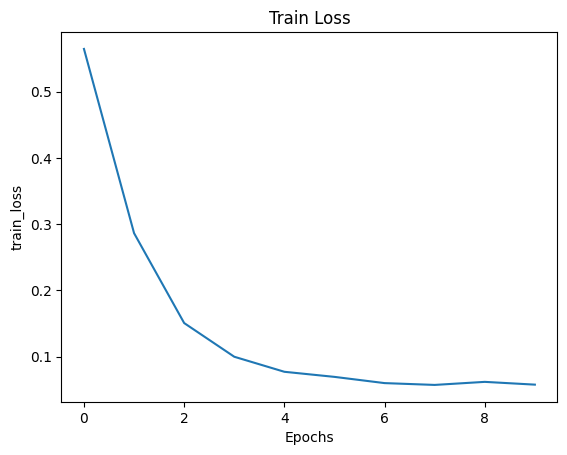

In [26]:
plt.plot(train_losses)
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.ylabel("train_loss")

plt.show()

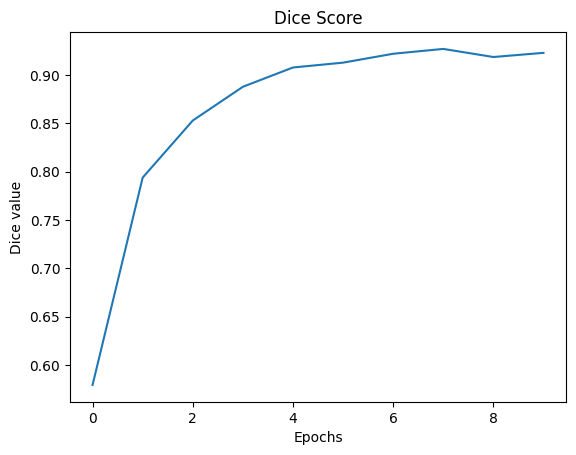

In [27]:
plt.plot(train_dices)
plt.title("Dice Score")
plt.xlabel("Epochs")
plt.ylabel("Dice value")

plt.show()

In [28]:
# TODO: Do these plots look good?
# TODO: YOUR ANSWER
# Yes, plots look good. The train loss is decreasing continously and settles towards the end of training implying the training was good.
# Dice metric's values keep increasing steadily which is also implies training went well.

## 5. Testing the U-Net. (20 points)

In [29]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0524
Test dice: 0.9318


In [30]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

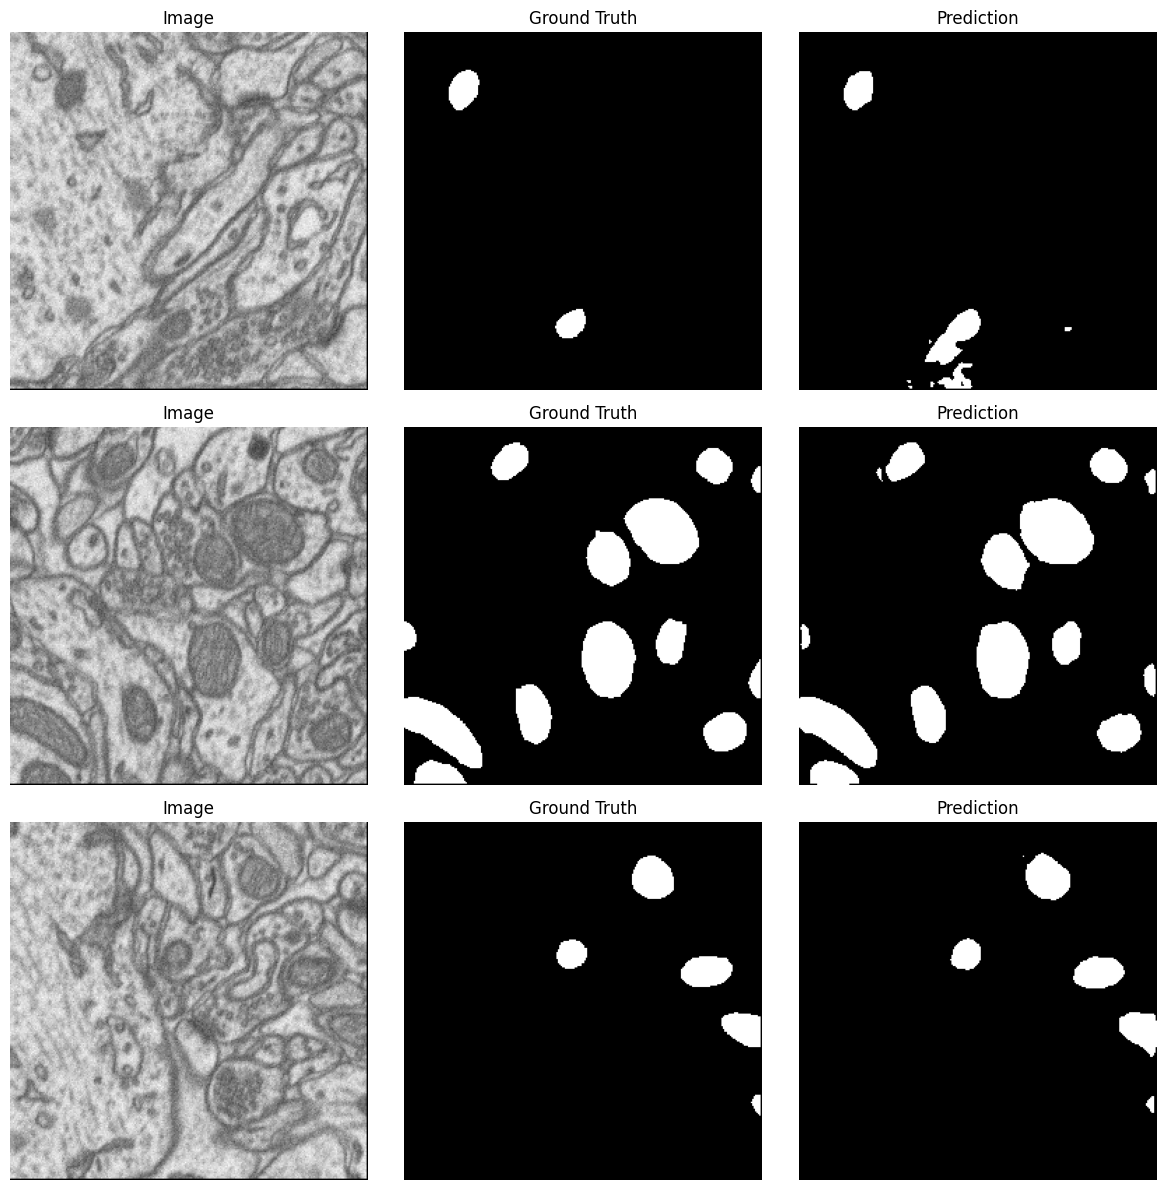

In [31]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [33]:
# TODO: Do you think the classifier works well?
# TODO: YOUR ANSWER
# Yes, overall the segmentations are similar to the ground truths but there are some slight issues in the predicted segmentations. In 
# image 1 there are some extra portions which are being labeled by the model which should not be. Images 2 and 3 are quite accurate but
# the classifier is including or not including some extra portions as segmentations which should not/should be there.

## Bonus: Improve the results. (33 points)

In [34]:
# Try to get better performance and show an improved Dice score on the test set!
# TODO: YOUR CODE!
# We try to use early stopping while increasing the number of epochs to improve the metrics.

In [35]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [36]:
model_bonus = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

optimizer_bonus = torch.optim.Adam(model_bonus.parameters(), lr=1e-3)

In [37]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

In [38]:
#
# TRAINING LOOP
#
num_epochs = 50

train_losses_bonus, val_losses_bonus = [], []
train_dices_bonus, val_dices_bonus = [], []

best_val_dice_bonus = 0.0

early_stopper = EarlyStopping(patience=10, min_delta=0.005)
for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model_bonus, train_loader, optimizer=optimizer_bonus)
    val_loss, val_dice = run_epoch(model_bonus, val_loader, optimizer=None)

    train_losses_bonus.append(train_loss)
    val_losses_bonus.append(val_loss)
    train_dices_bonus.append(train_dice)
    val_dices_bonus.append(val_dice)

    if val_dice > best_val_dice_bonus:
        best_val_dice_bonus = val_dice
        torch.save(model_bonus.state_dict(), "best_mito_model_bonus.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

    early_stopper(val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered")
        break

print("Best val dice:", best_val_dice_bonus)

Epoch 1/50 | train_loss=0.4034, train_dice=0.6424 | val_loss=0.6281, val_dice=0.0026
Epoch 2/50 | train_loss=0.1626, train_dice=0.8316 | val_loss=0.1186, val_dice=0.8599
Epoch 3/50 | train_loss=0.1030, train_dice=0.8751 | val_loss=0.1275, val_dice=0.8330
Epoch 4/50 | train_loss=0.0794, train_dice=0.9003 | val_loss=0.1481, val_dice=0.7930
Epoch 5/50 | train_loss=0.0714, train_dice=0.9056 | val_loss=0.0683, val_dice=0.9038
Epoch 6/50 | train_loss=0.0668, train_dice=0.9108 | val_loss=0.0659, val_dice=0.9159
Epoch 7/50 | train_loss=0.0573, train_dice=0.9246 | val_loss=0.0515, val_dice=0.9295
Epoch 8/50 | train_loss=0.0563, train_dice=0.9240 | val_loss=0.0461, val_dice=0.9409
Epoch 9/50 | train_loss=0.0541, train_dice=0.9264 | val_loss=0.0541, val_dice=0.9259
Epoch 10/50 | train_loss=0.0452, train_dice=0.9398 | val_loss=0.0422, val_dice=0.9421
Epoch 11/50 | train_loss=0.0403, train_dice=0.9465 | val_loss=0.0398, val_dice=0.9481
Epoch 12/50 | train_loss=0.0431, train_dice=0.9402 | val_loss=0

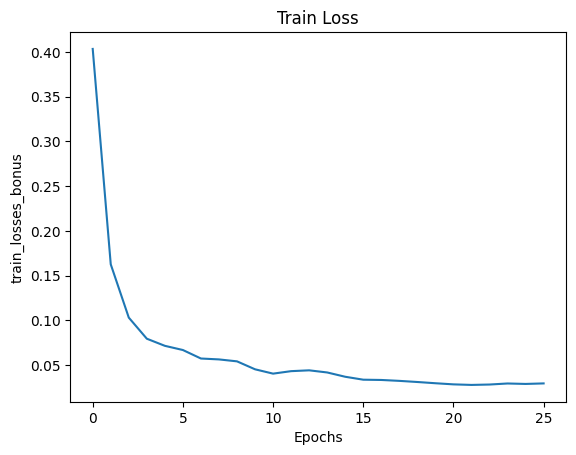

In [41]:
plt.plot(train_losses_bonus)
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.ylabel("train_losses_bonus")

plt.show()

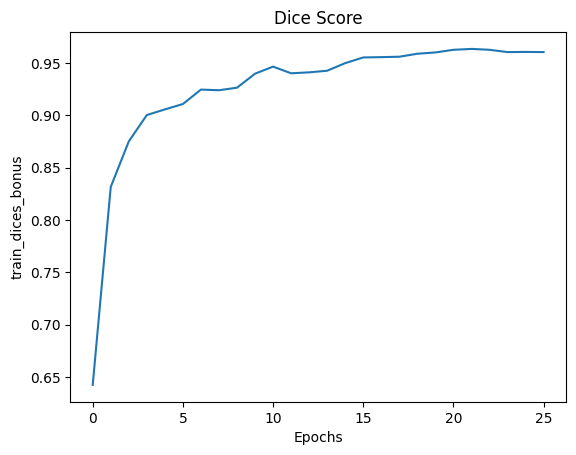

In [42]:
plt.plot(train_dices_bonus)
plt.title("Dice Score")
plt.xlabel("Epochs")
plt.ylabel("train_dices_bonus")

plt.show()

In [43]:
# EVALUATE THE MODEL ON THE TEST DATA
model_bonus.load_state_dict(torch.load("best_mito_model_bonus.pth", map_location=device))
test_loss, test_dice = run_epoch(model_bonus, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0265
Test dice: 0.9643


In [45]:
# So, by increasing the epochs and adding early stopping to avoid overfitting we are able to improve the score to:

# Test loss: 0.0265
# Test dice: 0.9643

In [ ]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#